# Task 2 – Statistical Feature Screening (Chi-square Test)
**AIMS Lab Research Engineer Selection – Shahriar** (mn9447109@gmail.com)

This notebook reproduces every number reported in Task 2 of the assignment: data overview, chi-square tests with Cramér's V and Benjamini–Hochberg correction, Fisher's exact test for sparse tables, Mann–Whitney tests for continuous variables, prevalence/screening-gap summaries, and two indicative predictive models.

**Dataset:** `test-dataset.xlsx` (place it in the same folder as this notebook, or edit `PATH` below).

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
pd.set_option("display.width", 140)

PATH = "test-dataset.xlsx"
d = pd.read_excel(PATH)
d.shape

(29999, 34)

## 1. Data overview and preparation

In [2]:
d["age_group"] = pd.cut(d.age, [-1, 17, 29, 44, 59, 200],
                        labels=["<18", "18-29", "30-44", "45-59", "60+"])
d["disability"] = (d.disabilities_name.astype(str) != "0").astype(int)
d["htn"] = d.profile_hypertensive.astype(int)   # target 1: hypertension
d["dm"] = d.diabetic.astype(int)                # target 2: diabetes
d["cvd"] = d.has_cardiovascular_disease
d["stroke"] = d.had_stroke

print(f"rows={len(d)}, households={d.household_id.nunique()}, duplicate user_id={d.user_id.duplicated().sum()}")
print(f"HTN cases={d.htn.sum()} ({d.htn.mean():.2%}), DM cases={d.dm.sum()} ({d.dm.mean():.2%}), "
      f"CVD={d.cvd.sum()}, stroke={d.stroke.sum()}")
print("is_poor unique values:", d.is_poor.unique(), "-> zero variance, excluded")
for c in ["BMI", "SUGAR", "SPO2", "MUAC"]:
    print(f"  {c}: measured for {d[c].notna().mean():.1%}")
print(f"age>100: {(d.age > 100).sum()}, age==0: {(d.age == 0).sum()}, min height: {d.HEIGHT.min():.1f}, "
      f"BMI range: {d.BMI.min():.1f}-{d.BMI.max():.1f}")

rows=29999, households=21449, duplicate user_id=0
HTN cases=1575 (5.25%), DM cases=601 (2.00%), CVD=34, stroke=23
is_poor unique values: [0] -> zero variance, excluded
  BMI: measured for 3.8%
  SUGAR: measured for 5.3%
  SPO2: measured for 14.5%
  MUAC: measured for 0.2%
age>100: 140, age==0: 25, min height: 35.6, BMI range: 1.6-67.9


## 2. Chi-square test of independence

For each feature X and outcome Y, build the contingency table of observed counts, compute
χ² = Σ (O − E)² / E with E = row total × column total / N, then Cramér's V for effect size and
Benjamini–Hochberg to control the false discovery rate across features.

In [3]:
def chi_square(x, y):
    """Pearson chi-square test of independence on complete cases."""
    m = pd.concat([x, y], axis=1).dropna()
    m.columns = ["x", "y"]
    table = pd.crosstab(m.x, m.y)
    chi2, p, dof, expected = stats.chi2_contingency(table, correction=False)  # E_ij = R_i*C_j/N
    n = table.values.sum()
    v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))                          # Cramer's V
    return dict(n=n, chi2=chi2, dof=dof, p=p, V=v,
                min_expected=expected.min(), pct_cells_lt5=(expected < 5).mean() * 100)

def benjamini_hochberg(p):
    """BH-adjusted q-values: q_(i) = min_{k>=i} (m/k) * p_(k)."""
    p = np.asarray(p)
    m = len(p)
    order = np.argsort(p)
    q = np.empty(m)
    prev = 1.0
    for rank, idx in zip(range(m, 0, -1), order[::-1]):
        prev = min(prev, p[idx] * m / rank)
        q[idx] = prev
    return q

features = {
    "union_name": "union_name", "age_group": "age_group", "total_income": "total_income",
    "gender": "gender", "disability": "disability", "is_freedom_fighter": "is_freedom_fighter",
    "had_stroke": "stroke", "has_cardiovascular_disease": "cvd",
    "RESULT_STAT_BP": "RESULT_STAT_BP", "RESULT_STAT_BMI": "RESULT_STAT_BMI",
    "RESULT_STAT_SUGAR": "RESULT_STAT_SUGAR", "TAG_NAME": "TAG_NAME",
    "RESULT_STAT_PR": "RESULT_STAT_PR", "RESULT_STAT_SPO2": "RESULT_STAT_SPO2",
    "diabetic": "dm", "profile_hypertensive": "htn",
}
targets = {"Hypertension": ("htn", "profile_hypertensive"), "Diabetes": ("dm", "diabetic")}

In [4]:
all_rows = []
for tname, (tcol, tfeature) in targets.items():
    rows = []
    for fname, col in features.items():
        if fname == tfeature:          # do not test a variable against itself
            continue
        r = chi_square(d[col], d[tcol])
        r.update(target=tname, feature=fname)
        rows.append(r)
    res = pd.DataFrame(rows)
    res["q_BH"] = benjamini_hochberg(res.p.values)
    res["significant"] = res.q_BH < 0.05
    all_rows.append(res)
    print(f"--- Target: {tname} ---")
    display(res[["feature", "n", "chi2", "dof", "p", "V", "q_BH", "significant", "min_expected"]]
            .sort_values("V", ascending=False).round(4))

chi_results = pd.concat(all_rows)
chi_results.to_csv("chi_square_results.csv", index=False)
chi_results.head()

--- Target: Hypertension ---


,feature,n,chi2,dof,p,V,q_BH,significant,min_expected
10,RESULT_STAT_SUGAR,1583,395.2104,6,0.0000,0.4997,0.0000,True,0.2704
14,diabetic,29999,3439.5630,1,0.0000,0.3386,0.0000,True,31.5536
0,union_name,29999,1611.1074,15,0.0000,0.2317,0.0000,True,5.5652
8,RESULT_STAT_BP,27600,1263.3828,6,0.0000,0.2140,0.0000,True,29.2049
1,age_group,29999,1328.2336,4,0.0000,0.2104,0.0000,True,143.1198
6,had_stroke,29999,246.6503,1,0.0000,0.0907,0.0000,True,1.2075
7,has_cardiovascular_disease,29999,241.8835,1,0.0000,0.0898,0.0000,True,1.7851
9,RESULT_STAT_BMI,1128,7.7890,5,0.1683,0.0831,0.1941,False,0.1835
12,RESULT_STAT_PR,27455,29.3468,2,0.0000,0.0327,0.0000,True,43.2572
4,disability,29999,31.4466,1,0.0000,0.0324,0.0000,True,3.6226


--- Target: Diabetes ---


,feature,n,chi2,dof,p,V,q_BH,significant,min_expected
10,RESULT_STAT_SUGAR,1583,1317.9573,6,0.0000,0.9125,0.0000,True,0.3108
14,profile_hypertensive,29999,3439.5630,1,0.0000,0.3386,0.0000,True,31.5536
0,union_name,29999,652.3847,15,0.0000,0.1475,0.0000,True,2.1236
1,age_group,29999,380.3535,4,0.0000,0.1126,0.0000,True,54.6127
8,RESULT_STAT_BP,27600,159.9843,6,0.0000,0.0761,0.0000,True,9.8139
7,has_cardiovascular_disease,29999,103.7913,1,0.0000,0.0588,0.0000,True,0.6812
9,RESULT_STAT_BMI,1128,2.2798,5,0.8092,0.0450,0.8092,False,0.0638
2,total_income,29999,38.4331,3,0.0000,0.0358,0.0000,True,14.2241
11,TAG_NAME,1583,1.8201,2,0.4025,0.0339,0.5489,False,1.0878
6,had_stroke,29999,27.7614,1,0.0000,0.0304,0.0000,True,0.4608


,n,chi2,dof,p,V,min_expected,pct_cells_lt5,target,feature,q_BH,significant
0,29999,1611.107443,15,0.000000e+00,0.231744,5.565186,0.0,Hypertension,union_name,0.000000e+00,True
1,29999,1328.233563,4,2.515616e-286,0.210418,143.119771,0.0,Hypertension,age_group,1.257808e-285,True
2,29999,9.958818,3,1.891946e-02,0.018220,37.276243,0.0,Hypertension,total_income,2.837919e-02,True
3,29999,2.223218,1,1.359494e-01,0.008609,355.069336,0.0,Hypertension,gender,1.699368e-01,False
4,29999,31.446633,1,2.049978e-08,0.032377,3.622621,25.0,Hypertension,disability,3.843709e-08,True


**Worked example (diabetic × hypertensive):** E = 601 × 1,575 / 29,999 = 31.6 for the (diabetic, hypertensive) cell versus an observed count of 349, giving χ² = 3,439.6 (df = 1, p < 0.001), V = 0.34, odds ratio ≈ 31.8 (confirmed with Fisher's exact test in Section 3).

## 3. Fisher's exact test for sparse 2×2 tables

Used where expected counts are small (rare outcomes: stroke, CVD, disability, freedom-fighter status).

In [5]:
for tcol in ["htn", "dm"]:
    for col in ["disability", "is_freedom_fighter", "stroke", "cvd"]:
        odds, p = stats.fisher_exact(pd.crosstab(d[col], d[tcol]).values)
        print(f"{tcol:>3} x {col:<18} OR={odds:8.2f}  p={p:.3g}")

odds, p = stats.fisher_exact(pd.crosstab(d.htn, d.dm).values)
print(f"htn x dm                  OR={odds:8.2f}  p={p:.3g}")
odds, p = stats.fisher_exact(pd.crosstab(d.stroke, d.cvd).values)
print(f"stroke x cvd              OR={odds:8.2f}  p={p:.3g}")
print(f"DM among hypertensive: {d[d.htn == 1].dm.mean():.1%};  among non-hypertensive: {d[d.htn == 0].dm.mean():.1%}")

htn x disability         OR=    4.63  p=1.16e-05
htn x is_freedom_fighter OR=    3.61  p=0.276
htn x stroke             OR=   65.71  p=2.19e-19
htn x cvd                OR=   33.54  p=1.81e-20
 dm x disability         OR=    1.46  p=0.404
 dm x is_freedom_fighter OR=    0.00  p=1
 dm x stroke             OR=   10.36  p=0.00104
 dm x cvd                OR=   17.86  p=1.64e-08
htn x dm                  OR=   31.82  p=3.02e-293
stroke x cvd              OR=  377.50  p=1.32e-13
DM among hypertensive: 22.2%;  among non-hypertensive: 0.9%


## 4. Continuous variables (Mann–Whitney U test)

In [6]:
for tname, (tcol, _) in targets.items():
    for c in ["age", "SYSTOLIC", "DIASTOLIC", "BMI", "SUGAR", "PULSE_RATE", "SPO2", "HEIGHT", "WEIGHT"]:
        m = d[[c, tcol]].dropna()
        a, b = m[m[tcol] == 1][c], m[m[tcol] == 0][c]
        u = stats.mannwhitneyu(a, b)
        print(f"{tname:<12} {c:<11} n={len(m):>6}  median(case)={a.median():7.2f}  "
              f"median(non-case)={b.median():7.2f}  p={u.pvalue:.3g}")

Hypertension age         n= 29999  median(case)=  52.00  median(non-case)=  36.00  p=2.54e-296
Hypertension SYSTOLIC    n= 27600  median(case)= 137.00  median(non-case)= 119.00  p=1.82e-237
Hypertension DIASTOLIC   n= 27600  median(case)=  82.00  median(non-case)=  75.00  p=1.85e-108
Hypertension BMI         n=  1128  median(case)=  25.68  median(non-case)=  21.95  p=0.0607
Hypertension SUGAR       n=  1583  median(case)=  10.18  median(non-case)=   7.87  p=8.76e-08
Hypertension PULSE_RATE  n= 27455  median(case)=  80.00  median(non-case)=  84.00  p=3.06e-14
Hypertension SPO2        n=  4345  median(case)=  99.00  median(non-case)=  99.00  p=0.0305
Hypertension HEIGHT      n=  1128  median(case)= 157.48  median(non-case)= 152.40  p=0.235
Hypertension WEIGHT      n=  1128  median(case)=  57.00  median(non-case)=  50.00  p=0.00831
Diabetes     age         n= 29999  median(case)=  50.00  median(non-case)=  37.00  p=7.28e-85
Diabetes     SYSTOLIC    n= 27600  median(case)= 130.00  median(n

## 5. Prevalence, hotspots and screening gaps

In [7]:
prevalence_by_age = (d.groupby("age_group", observed=True)[["htn", "dm"]].mean() * 100).round(2)
display(prevalence_by_age)

prevalence_by_union = (d.groupby("union_name")[["htn", "dm"]].mean() * 100).round(1).sort_values("htn", ascending=False)
display(prevalence_by_union)

high_bp = d.RESULT_STAT_BP.isin(["Mild High", "Moderate High", "Severe High"]) & (d.htn == 0)
print("High BP reading but not flagged hypertensive:", int(high_bp.sum()))
print("Sugar status 'DIABETIC (need confirmation)' but not flagged diabetic:",
      int(((d.RESULT_STAT_SUGAR == "DIABETIC (need confirmation)") & (d.dm == 0)).sum()))

,htn,dm
age_group,,
<18,0.00,0.00
18-29,0.41,0.24
30-44,3.48,1.55
45-59,9.84,4.16
60+,13.58,3.72


,htn,dm
union_name,,
BARUIPARA,24.3,8.9
ELIOTGANJ DAKKHIN,10.6,6.5
CHERAGPUR,10.1,2.7
MAJITPUR,9.9,6.8
BILASHBARI,9.6,3.5
GABTALI SADAR,8.1,4.5
UTHALI,5.2,4.3
BARATARA,5.2,1.9
TENTULBARIA,2.9,1.2


High BP reading but not flagged hypertensive: 5036
Sugar status 'DIABETIC (need confirmation)' but not flagged diabetic: 497


### Summary figure
(a) Prevalence of hypertension and diabetes by age group. (b) Cramér's V (association strength) for the main features, for each outcome.

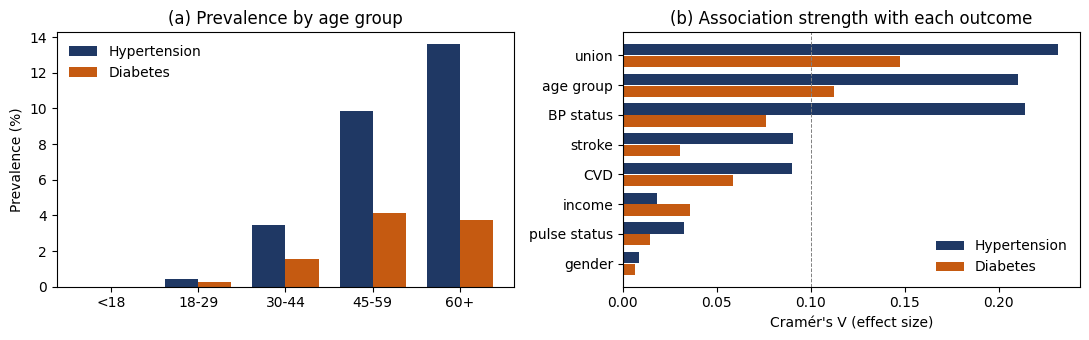

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))

# (a) prevalence by age group
g = d.groupby("age_group", observed=True)[["htn", "dm"]].mean() * 100
x = np.arange(len(g)); w = 0.38
ax[0].bar(x - w/2, g.htn, w, label="Hypertension", color="#1F3864")
ax[0].bar(x + w/2, g.dm, w, label="Diabetes", color="#C55A11")
ax[0].set_xticks(x); ax[0].set_xticklabels(g.index)
ax[0].set_ylabel("Prevalence (%)")
ax[0].set_title("(a) Prevalence by age group")
ax[0].legend(frameon=False)

# (b) Cramer's V for key features
sel = ["union_name", "age_group", "RESULT_STAT_BP", "had_stroke", "has_cardiovascular_disease",
       "total_income", "RESULT_STAT_PR", "gender"]
lab = ["union", "age group", "BP status", "stroke", "CVD", "income", "pulse status", "gender"]
h = chi_results[(chi_results.target == "Hypertension") & chi_results.feature.isin(sel)].set_index("feature").V
dm_v = chi_results[(chi_results.target == "Diabetes") & chi_results.feature.isin(sel)].set_index("feature").V
y = np.arange(len(sel))[::-1]
ax[1].barh(y + 0.2, [h[o] for o in sel], 0.38, color="#1F3864", label="Hypertension")
ax[1].barh(y - 0.2, [dm_v[o] for o in sel], 0.38, color="#C55A11", label="Diabetes")
ax[1].set_yticks(y); ax[1].set_yticklabels(lab)
ax[1].set_xlabel("Cramér's V (effect size)")
ax[1].axvline(0.1, ls="--", lw=0.7, color="gray")
ax[1].set_title("(b) Association strength with each outcome")
ax[1].legend(frameon=False)

plt.tight_layout()
plt.savefig("fig_summary.png", dpi=150)
plt.show()

## 6. Indicative predictive models (30% stratified hold-out)

In [9]:
base = pd.get_dummies(d[["age", "gender", "total_income", "union_name"]], drop_first=True).astype(float)
vit = d[["SYSTOLIC", "DIASTOLIC", "PULSE_RATE"]]
sets = {"demographics": base, "demographics+vitals": pd.concat([base, vit.fillna(vit.median())], axis=1)}

for tcol in ["htn", "dm"]:
    for name, X in sets.items():
        Xtr, Xte, ytr, yte = train_test_split(X, d[tcol], test_size=0.3, random_state=42, stratify=d[tcol])
        mu, sd = Xtr.mean(), Xtr.std().replace(0, 1)
        lr = LogisticRegression(max_iter=2000, class_weight="balanced").fit((Xtr - mu) / sd, ytr)
        gb = GradientBoostingClassifier(random_state=0).fit(Xtr, ytr)
        print(f"{tcol:>3} | {name:<20} LR AUC={roc_auc_score(yte, lr.predict_proba((Xte - mu) / sd)[:, 1]):.3f}"
              f"   GB AUC={roc_auc_score(yte, gb.predict_proba(Xte)[:, 1]):.3f}")

htn | demographics         LR AUC=0.876   GB AUC=0.886


htn | demographics+vitals  LR AUC=0.907   GB AUC=0.917


 dm | demographics         LR AUC=0.856   GB AUC=0.864


 dm | demographics+vitals  LR AUC=0.866   GB AUC=0.872


## Notes / limitations
- Data is cross-sectional: results show association, not causation.
- People within the same household are not independent, so p-values are approximate.
- `RESULT_STAT_*` fields are derived from the raw measurements (e.g. `RESULT_STAT_SUGAR` from `SUGAR`), so testing them together with the raw value is partly circular.
- Data cleaning is needed for a few implausible values: age (140 records above 100 years, 25 aged 0), height (minimum 35.6 cm), BMI (range 1.6–67.9).